## Shock tube test

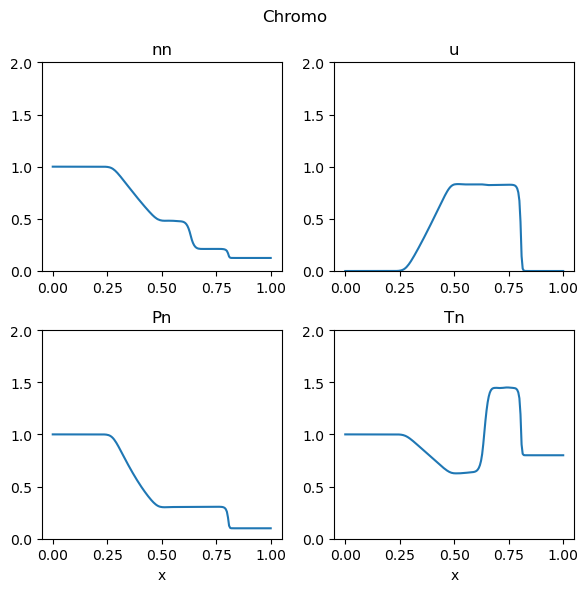

In [5]:
import numpy as np

def read_XIII(filename):
    xn_I = np.zeros(n_elem)
    xn_III = np.zeros((ns,n_eq))
    with open(filename) as f:
        for i in range(n_elem):
            xn_I[i] = float(f.readline())

    for i in range(ns):
        for k in range(n_eq):
            xn_III[i,k] = xn_I[sub2ind([ns,n_eq],i,k)]
    return xn_III

def sub2ind(siz, row, col, slice):
    s_n_rows = siz[0]
    s_n_cols = siz[1]
    return (slice * s_n_rows * s_n_cols) + (col * s_n_rows) + row

def sub2ind(siz, row, col):
    s_n_rows = siz[0]
    s_n_cols = siz[1]
    return col * s_n_rows + row

CNI = 0;        # Ion density
CNN = 1;        # Neutral density
CNV = 2;        # Ion velocity
CNU = 3;        # Neutral velocity
CEI = 4;        # Ion energy
CEN = 5;        # Neutral energy
# Primitive Variable Indices
PNI = 0;        # Ion density
PNN = 1;        # Neutral density
PV  = 2;        # Ion velocity
PU  = 3;        # Neutral velosity
PPI = 4;        # Ion pressure
PPN = 5;        # Neutral pressure

ns = 200
n_eq = 6
n_elem = ns*n_eq

xn_III = read_XIII('../chromo_build/output.txt')

nn = xn_III[:,PNN]
ni = xn_III[:,PNI]
uu = xn_III[:,PU]
vv = xn_III[:,PV]
pi = xn_III[:,PPI]
pn = xn_III[:,PPN]
Tn = pn/nn
xx = np.linspace(0,1,ns)

import matplotlib.pyplot as plt
# 4 subplots
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(6, 6))
fig.suptitle('Chromo')
axs[0,0].plot(xx,nn)
axs[0,0].set_title('nn')
axs[0,0].set_ylim([0,2])

axs[0,1].plot(xx,uu)
axs[0,1].set_title('u')
axs[0,1].set_ylim([0,2])

axs[1,0].plot(xx,pn)
axs[1,0].set_title('Pn')
axs[1,0].set_ylim([0,2])
axs[1,0].set_xlabel('x')

axs[1,1].plot(xx,Tn)
axs[1,1].set_title('Tn')
axs[1,1].set_ylim([0,2])
axs[1,1].set_xlabel('x')

plt.tight_layout()
plt.show()

## Accuracy test

40 6
80 6
160 6
320 6
1000 6
interpolating NN
L = 18, R = 22
L = 34, R = 46
L = 66, R = 94
L = 130, R = 190
slope =  1.2298538108649026


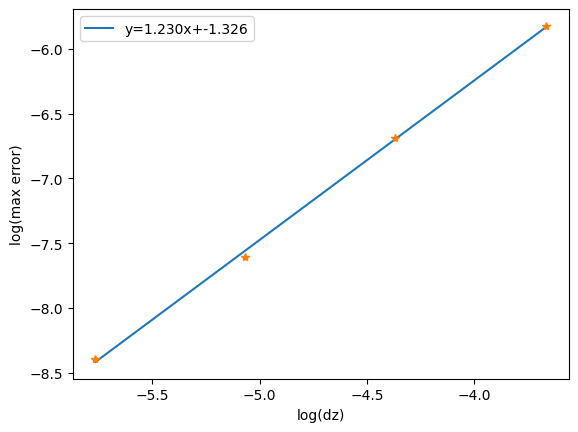

[0.02564103 0.01265823 0.00628931 0.0031348 ]
[0.00295512 0.0012446  0.00049881 0.00022696]


In [7]:
import numpy as np

def sub2ind(siz, row, col, slice):
    s_n_rows = siz[0]
    s_n_cols = siz[1]
    return (slice * s_n_rows * s_n_cols) + (col * s_n_rows) + row

def sub2ind(siz, row, col):
    s_n_rows = siz[0]
    s_n_cols = siz[1]
    return col * s_n_rows + row

CNI = 0;        # Ion density
CNN = 1;        # Neutral density
CNV = 2;        # Ion velocity
CNU = 3;        # Neutral velocity
CEI = 4;        # Ion energy
CEN = 5;        # Neutral energy
# Primitive Variable Indices
PNI = 0;        # Ion density
PNN = 1;        # Neutral density
PV  = 2;        # Ion velocity
PU  = 3;        # Neutral velosity
PPI = 4;        # Ion pressure
PPN = 5;        # Neutral pressure

n_eq = 6

def interp(xp, yp, xq):
    yq = np.zeros(len(xq))
    for i in range(len(xq)):
        dx_accu = xp[1]-xp[0]
        i_accu = int((xq[i]-xp[0])/dx_accu)
        if i_accu == len(xp)-1:
            yq[i] = yp[-1]
        else:
            yq[i] = yp[i_accu] + (yp[i_accu+1]-yp[i_accu])*(xq[i]-xp[i_accu])/(xp[i_accu+1]-xp[i_accu])
    return yq

def get_norm(x):
    # return std of x
    dz = 1.0/len(x)
    L = int(0.4/dz)+2
    R = int(0.6/dz)-1
    print(f"L = {L}, R = {R}")
    # print(f"error = {x[L:R]}")
    return np.max(np.abs(x)*dz)

def get_max_error(x_test, y_test, x_accu, y_accu):
    y_accu_interp = interp(x_accu, y_accu, x_test)
    return get_norm(y_test-y_accu_interp)

def read_XIII(filename, ns, n_eq):
    print(ns, n_eq)
    n_elem = ns*n_eq
    xn_I = np.zeros(n_elem)
    xn_III = np.zeros((ns,n_eq))
    with open(filename) as f:
        for i in range(n_elem):
            xn_I[i] = float(f.readline())

    for i in range(ns):
        for k in range(n_eq):
            xn_III[i,k] = xn_I[sub2ind([ns,n_eq],i,k)]
    return xn_III

data_dir = '../chromo_build/'

ns_test = [40, 80, 160, 320]
ds_test = 1/(np.array(ns_test)-1)
ns_accu = 1000
filenames = [data_dir + 'output_'+str(ns)+'.txt' for ns in ns_test]
xn_III_test = [read_XIII(filename, ns, n_eq) for filename,ns in zip(filenames,ns_test)]
xn_III_accu = read_XIII(data_dir + 'output_'+str(ns_accu)+'.txt', ns_accu, n_eq)

max_errors = np.zeros(len(ns_test))
# use NN
IND = PNN
print("interpolating NN")

uu_accu = xn_III_accu[:,IND]
xx_accu = np.linspace(0,1,ns_accu)

# print('nn accu = ', uu_accu)

for i in range(len(ns_test)):
    uu_test = xn_III_test[i][:,IND]
    xx_test = np.linspace(0,1,ns_test[i])
    max_errors[i] = get_max_error(xx_test, uu_test, xx_accu, uu_accu)

from matplotlib import pyplot as plt
log_dx_test = np.log(ds_test)
log_max_errors = np.log(max_errors)

# linear fit log_dz vs log_max_errors
from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(log_dx_test, log_max_errors)
# plot the fitted line

plt.plot(log_dx_test, slope*log_dx_test + intercept, label=f'y={slope:.3f}x+{intercept:.3f}')
print('slope = ', slope)

plt.plot(log_dx_test, log_max_errors, '*')
plt.xlabel('log(dz)')
plt.ylabel('log(max error)')
plt.legend()
plt.show()
print(ds_test)
print(max_errors)

### Model C7

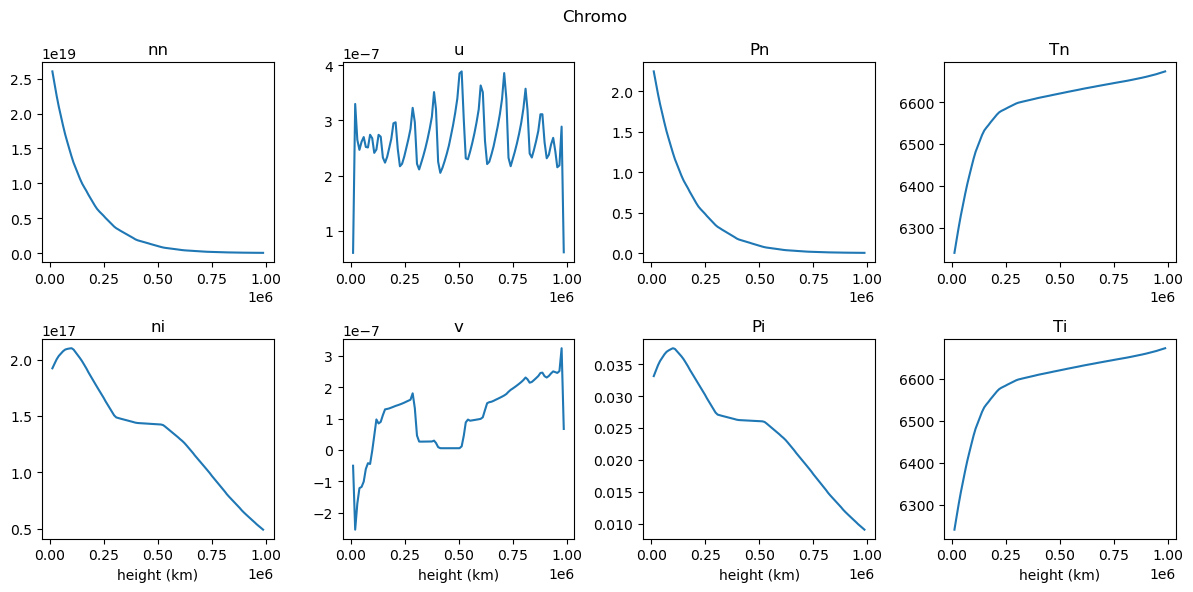

In [68]:
import numpy as np

def read_XIII(filename):
    # Read the entire file
    with open(filename, 'r') as file:
        lines = file.readlines()

    # Read the first line and store it in xx as a numpy array
    xx = np.array([float(x) for x in lines[0].split()])

    # Determine ns and n_eq from the shape of the data
    ns = len(xx)  # Number of elements in the first line
    n_eq = len(lines[1].split())  # Number of columns in the rest of the data (determined by the second line)

    # Now read the remaining lines and store the data in xn_III
    xn_III = np.zeros((ns, n_eq))  # Initialize an array for ns rows and n_eq columns

    # Populate xn_III with the remaining data
    for i in range(1, ns+1):  # Start from the second line
        xn_III[i-1, :] = np.array([float(x) for x in lines[i].split()])
    return xx, xn_III

def sub2ind(siz, row, col, slice):
    s_n_rows = siz[0]
    s_n_cols = siz[1]
    return (slice * s_n_rows * s_n_cols) + (col * s_n_rows) + row

def sub2ind(siz, row, col):
    s_n_rows = siz[0]
    s_n_cols = siz[1]
    return col * s_n_rows + row

CNI = 0;        # Ion density
CNN = 1;        # Neutral density
CNV = 2;        # Ion velocity
CNU = 3;        # Neutral velocity
CEI = 4;        # Ion energy
CEN = 5;        # Neutral energy
# Primitive Variable Indices
PNI = 0;        # Ion density
PNN = 1;        # Neutral density
PV  = 2;        # Ion velocity
PU  = 3;        # Neutral velosity
PPI = 4;        # Ion pressure
PPN = 5;        # Neutral pressure

ns = 100
n_eq = 6
n_elem = ns*n_eq

gammamono = 5.0 / 3.0  # Ratio of specific heats (adiabatic index for a monatomic ideal gas)
alpha_p = 0.18  # Divergence error propagation parameter
pi = 3.14159265358979323846  # Value of π (pi)
m_i = 1.6726219e-27  # Mass of proton in kilograms

m_n = m_i  # Mass of neutron equals mass of proton
m_e = 9.10938356e-31  # Mass of electron in kilograms
g = 0.27395e3  # Gravitational acceleration in normalized units (km/s^2)
k_b = 1.380649e-23  # Boltzmann constant in SI units
e_ = 1.602176634e-19  # Elementary charge in Coulombs

xx, xn_III = read_XIII('../chromo_build/output.txt')

nn = xn_III[:,CNN]/m_n
ni = xn_III[:,CNI]/m_i
uu = xn_III[:,CNU]/(m_n*nn)
vv = xn_III[:,CNV]/(m_n*ni)
pi = 2.0/3.0*xn_III[:,CEI] - 1.0/3.0*m_i*ni*vv*vv
pn = 2.0/3.0*xn_III[:,CEN] - 1.0/3.0*m_n*nn*uu*uu
Ti = pi/(2.0*ni*k_b)
Tn = pn/(nn*k_b)

import matplotlib.pyplot as plt
# 4 subplots
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(12, 6))
fig.suptitle('Chromo')
axs[0,0].plot(xx,nn)
axs[0,0].set_title('nn')

axs[1,0].plot(xx,ni)
axs[1,0].set_title('ni')
axs[1,0].set_xlabel('height (km)')

axs[0,1].plot(xx,uu)
axs[0,1].set_title('u')

axs[1,1].plot(xx,vv)
axs[1,1].set_title('v')
axs[1,1].set_xlabel('height (km)')

axs[0,2].plot(xx,pn)
axs[0,2].set_title('Pn')

axs[1,2].plot(xx,pi)
axs[1,2].set_title('Pi')
axs[1,2].set_xlabel('height (km)')

axs[0,3].plot(xx,Tn)
axs[0,3].set_title('Tn')

axs[1,3].plot(xx,Ti)
axs[1,3].set_title('Ti')
axs[1,3].set_xlabel('height (km)')

plt.tight_layout()
plt.show()